# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Fredda Nyarko
**Student ID:** 92632028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

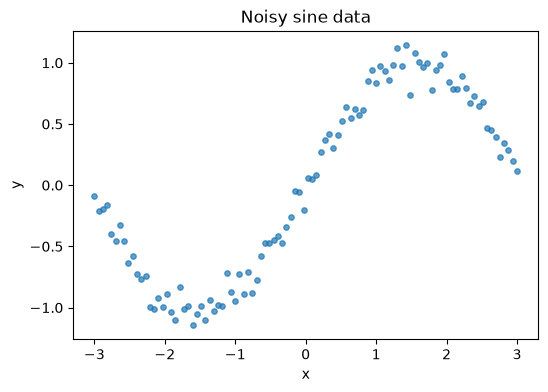

Final w = 0.3390328433849219, b = -0.010384651880467268, loss = 0.19545179713962046


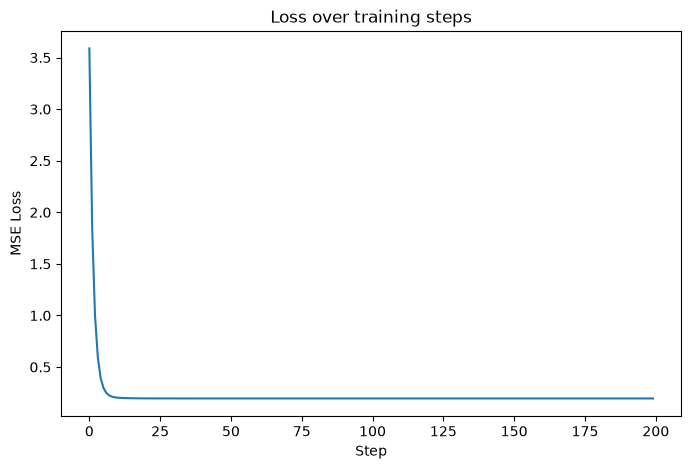

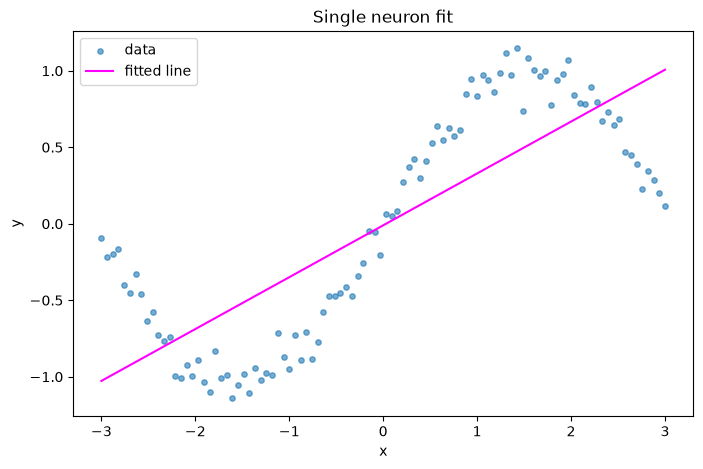

In [ ]:
# Generate the toy data
x = np.linspace(-3, 3, 100).reshape(-1,1)
y = np.sin(x) + np.random.normal(0,0.1,(100,1))

#   Plot it.
plt.figure(figsize = (6,4))
plt.scatter(x,y, s = 15, alpha = 0.7)
plt.title("Noisy sine data")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

# Initialise w and b to small random values.
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5

# Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.05
steps = 200
losses = []
for step in range(steps):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)  
    losses.append(loss)             # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
print(f"Final w = {w}, b = {b}, loss = {losses[-1]}")

# (a) the loss curve over the 200 steps
plt.figure(figsize = (8,5))
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()


# (b) the data with the fitted line on top.
plt.figure(figsize = (8,5))
plt.scatter(x, y, s= 15 , alpha = 0.6, label = "data")
plt.plot(x, w * x + b, color = "magenta", label = "fitted line")
plt.legend()
plt.title("Single neuron fit")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 1. ![My derivation](images/Derivative_by_hand.jpg)
2. This is underfitting because a single neuron only computes y_hat = w * x + b, which is a straight line. No matter how long you train, a straight line can never bend to match a curve like sine because the loss stops improving when the medel has already found the best possible straight line. the model is not complex enough to represent the shape of the data.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss:  0.014841292390220518


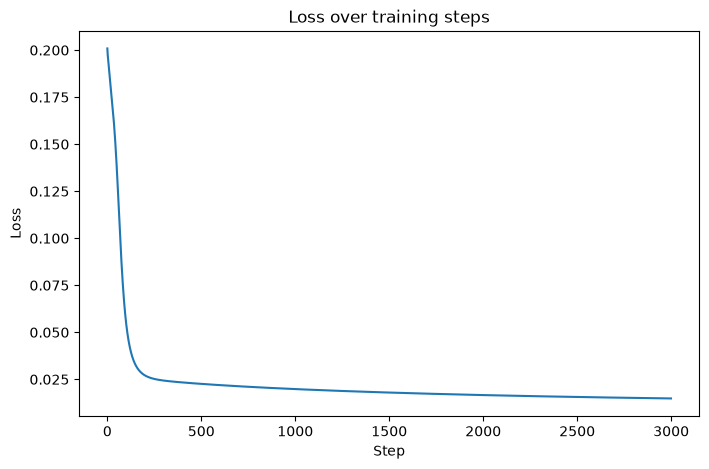

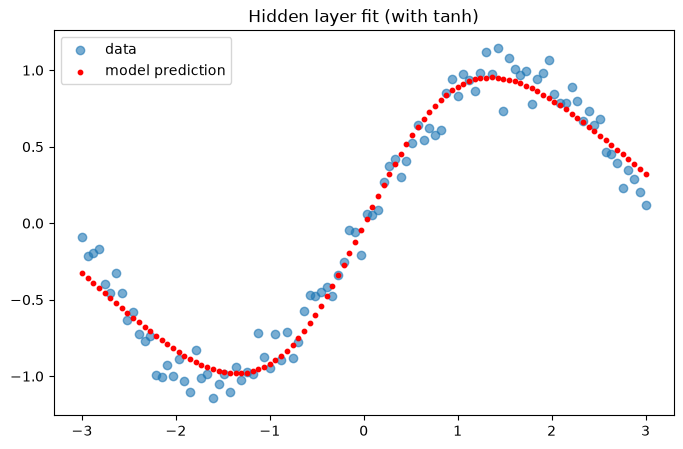

Final loss:  0.19545179915225414


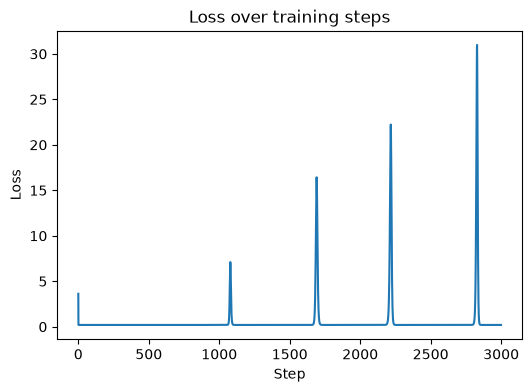

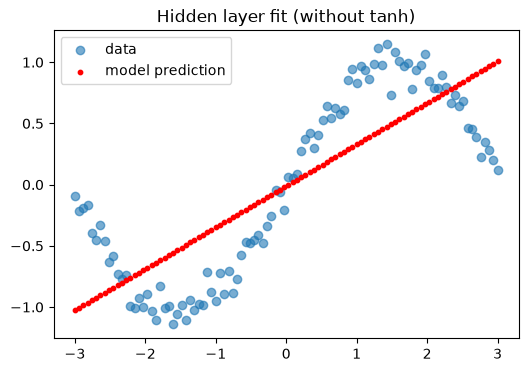

In [ ]:
# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros (1)

# Forward pass (keep the intermediate values — you need them for backprop):
lr = 0.05
steps = 3000
losses = []
for i in range(steps):
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat = h @ W2 + b2     # output, shape (100, 1)
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

# Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

print ("Final loss: ", losses[-1])

# Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="data", alpha=0.6)
plt.scatter(x, y_hat, color="red", label="model prediction", s=10)
plt.legend()
plt.title("Hidden layer fit (with tanh)")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros (1)

# Forward pass (keep the intermediate values — you need them for backprop):
lr = 0.05
steps = 3000
losses = []
for i in range(steps):
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = z1                 # activation
    y_hat = h @ W2 + b2     # output, shape (100, 1)
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

# Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

# updating weights
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

print ("Final loss: ", losses[-1])

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="data", alpha=0.6)
plt.scatter(x, y_hat, color="red", label="model prediction", s=10)
plt.legend()
plt.title("Hidden layer fit (without tanh)")
plt.show()



**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 1. without the activation function(tanh), every layer performs only a liner transformation, so the network behaves like one big linear model.Therefore, it cannot learn the nonlinear shape of the sine function, even with multiple hidden neurons.
2.  

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

C:\Users\fredd\AppData\Roaming\Python\Python312\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\fredd\AppData\Local\Temp\ipykernel_33640\3935756540.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\fredd\AppData\Local\Temp\ipykernel_33640\3935756540.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\fredd\AppData\Local\Temp\ipykernel_33640\3935756540.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
C:\Users\fredd\AppData\Roaming\Python\Python312\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


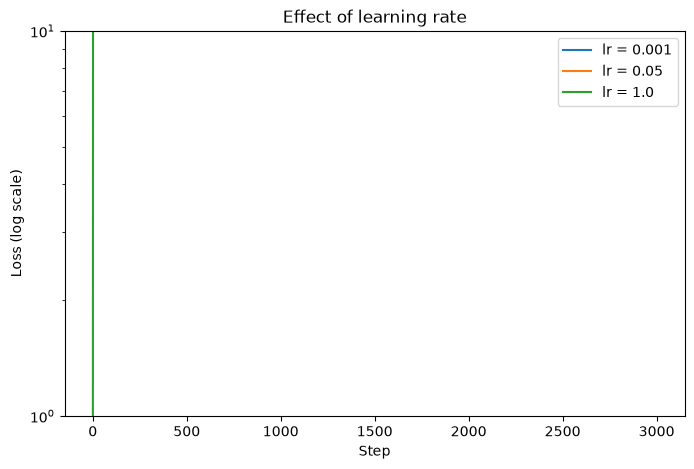

In [ ]:
# Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
def train_toy(lr, steps = 3000):
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.rand(8,) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.rand(1,) * 0.5
    
    losses = []

    for i in range(steps):
        # forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # update
        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2

    return losses

# Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

# Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8, 5))
plt.plot(losses_low, label="lr = 0.001")
plt.plot(losses_mid, label="lr = 0.05")
plt.plot(losses_high, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of learning rate")
plt.legend()
plt.show()




**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** With a learning rate of 0.001, the loss decreases very slowly because each parameter update is small. The network learns steadily but requires many iterations to converge. With a learning rate of 0.05, the loss decreases quickly and smoothly, reaching a much lower value in fewer steps. This provides a good balance between learning speed and stability. With a learning rate of 1.0, the loss becomes unstable and may oscillate or even increase because each update is too large, causing the optimizer to repeatedly overshoot the minimum instead of moving towards it. A learning rate that is too large therefore prevents convergence rather than making learning faster.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

obesity.head()

# Encode categoricals exactly as you did in Lab 2
# Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS).
caec_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(caec_order)
obesity["CALC"] = obesity["CALC"].map(calc_order)

obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)

# engineer a domain feature
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Encode the target `NObeyesdad` into integer class labels
le = LabelEncoder()
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])


X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]


# Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify = y,random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify = y_train_val, random_state=RANDOM_STATE
)

# Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.long)
y_val= torch.tensor(y_val.values, dtype = torch.long)
y_test = torch.tensor(y_test.values, dtype = torch.long)

train_dataset = TensorDataset(X_train,y_train)
val_dataset = TensorDataset(X_val,y_val)
test_dataset = TensorDataset(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

print("Training samples: ", len(train_dataset))
print("Validation samples: ", len(val_dataset))
print("Testing samples: ", len(test_dataset))

Train: (1266, 20)
Validation: (422, 20)
Test: (423, 20)
Training samples:  1266
Validation samples:  422
Testing samples:  423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes = (64,32), n_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_sizes[0],hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(hidden_sizes[1],n_classes)

        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.output(x)

        return x
        
# Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim)
model = model.to(DEVICE)

print(model)

# Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)

total_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters: ", total_par)

#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

first_layer = input_dim*64+64
print("Count:", first_layer)



FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=32, out_features=7, bias=True)
)
Trainable Parameters:  3655
Count: 1344


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 5/50 | Train Loss: 0.6696605160832405 | Validation Loss: 0.6424867361783981 | Val Loss: 0.6424867361783981 | Val Acc: 0.8246445497630331
Epoch 10/50 | Train Loss: 0.29905843585729597 | Validation Loss: 0.3543557567255838 | Val Loss: 0.3543557567255838 | Val Acc: 0.8696682464454977
Epoch 15/50 | Train Loss: 0.16855412190780045 | Validation Loss: 0.24530991911888123 | Val Loss: 0.24530991911888123 | Val Acc: 0.9123222748815166
Epoch 20/50 | Train Loss: 0.10709636257961393 | Validation Loss: 0.207432322204113 | Val Loss: 0.207432322204113 | Val Acc: 0.9312796208530806
Epoch 25/50 | Train Loss: 0.07020227862522006 | Validation Loss: 0.19609227084687778 | Val Loss: 0.19609227084687778 | Val Acc: 0.919431279620853
Epoch 30/50 | Train Loss: 0.04820505166426301 | Validation Loss: 0.1977373787334987 | Val Loss: 0.1977373787334987 | Val Acc: 0.933649289099526
Epoch 35/50 | Train Loss: 0.034043889748863874 | Validation Loss: 0.20295406305896385 | Val Loss: 0.20295406305896385 | Val Acc: 0.9

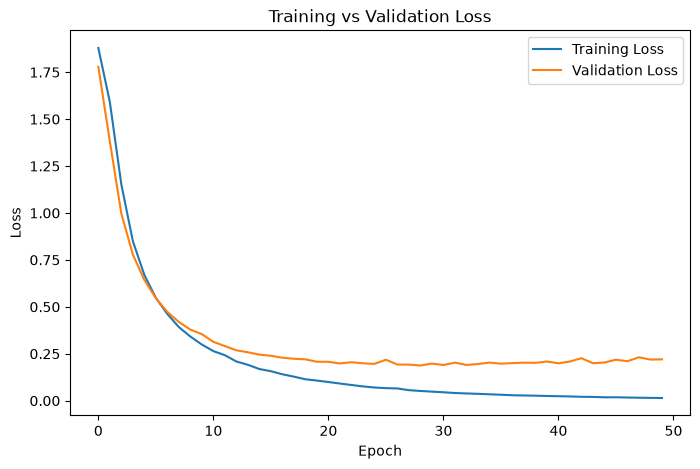

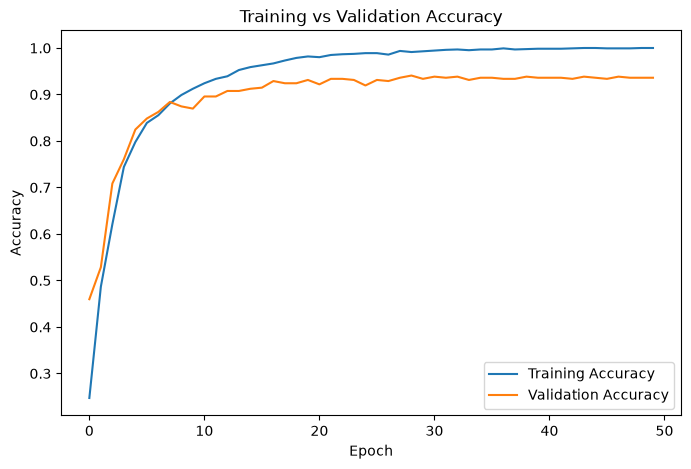

In [ ]:
model = FeedForwardNet(input_dim).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# Train for at least 50 epochs. Each epoch:
epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

for epoch in range(epochs):
        model.train()
        running_train_loss = 0
        correct_train = 0
        total_train = 0

        for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()          # <- the backprop you wrote by hand in Part 1.2
                optimizer.step()         # <- the update rule you wrote in Part 1.1

                running_train_loss += loss.item()
                predictions = torch.argmax(logits,dim=1)
                correct_train += (predictions == yb).sum().item()
                total_train += yb.size(0)

        epoch_train_loss = running_train_loss/len(train_loader)
        epoch_train_accuracy = correct_train/total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets

        model.eval()
        running_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
                for xb, yb in val_loader:
                        xb = xb.to(DEVICE)
                        yb = yb.to(DEVICE)

                        logits = model(xb)
                        loss = criterion(logits, yb)

                        running_val_loss += loss.item()
                        predictions = torch.argmax(logits,dim=1)
                        correct_val += (predictions == yb).sum().item()
                        total_val += yb.size(0)

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_accuracy = correct_val/total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

#   3. Append everything to history lists; print a one-line summary per epoch.

        if(epoch + 1 )% 5 == 0:
                print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_train_loss} | Validation Loss: {epoch_val_loss} | Val Loss: {epoch_val_loss} | Val Acc: {epoch_val_accuracy}")

# Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

        if epoch_val_loss < best_val_loss:

                best_val_loss = epoch_val_loss

                torch.save(model.state_dict(), "ffn_best.pt")


model.load_state_dict(torch.load("ffn_best.pt"))

# Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):

        super().__init__()

        layers = []
        in_features = input_dim

        # Build hidden layers
        for hidden_size in hidden_sizes:

            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = hidden_size

        # Output layer
        layers.append(nn.Linear(in_features, n_classes))

        self.network = nn.Sequential(*layers)

    
    def forward(self, x):
        return self.network(x)

Starting training: hidden_sizes=(8,), lr=0.001, dropout=0.0
Starting training: hidden_sizes=(64, 32), lr=0.001, dropout=0.0
Starting training: hidden_sizes=(256, 128), lr=0.001, dropout=0.0


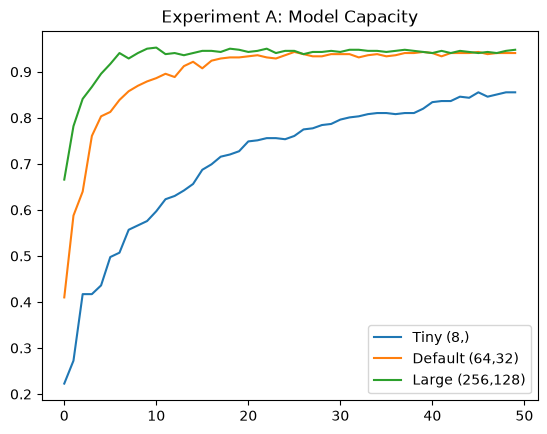

Starting training: hidden_sizes=(64, 32), lr=0.0001, dropout=0.0
Starting training: hidden_sizes=(64, 32), lr=0.001, dropout=0.0
Starting training: hidden_sizes=(64, 32), lr=0.1, dropout=0.0


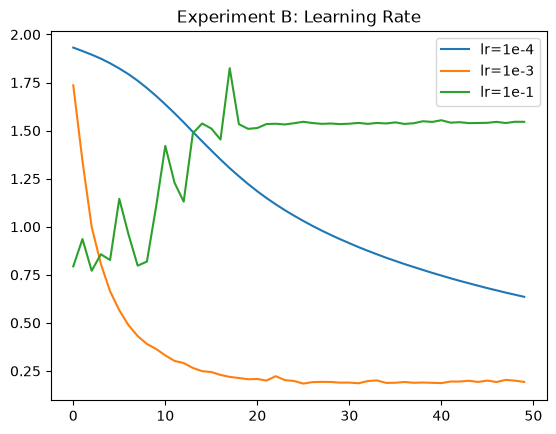

Starting training: hidden_sizes=(256, 128), lr=0.001, dropout=0.0
Starting training: hidden_sizes=(256, 128), lr=0.001, dropout=0.3


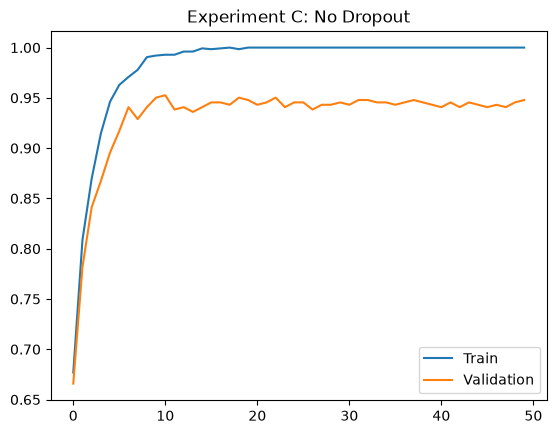

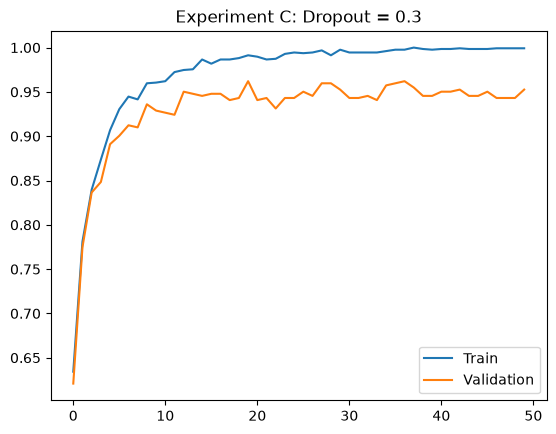

In [ ]:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)
    print(f"Starting training: hidden_sizes={hidden_sizes}, lr={lr}, dropout={dropout}")

    input_dim = X_train.shape[1]
    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_accuracy = 0

    for epoch in range(epochs):
        # ---- training pass ----
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # ---- evaluation pass ----
        model.eval()
        with torch.no_grad():
            train_loss = 0
            train_correct = 0
            train_total = 0
            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                predictions = torch.argmax(logits, dim=1)

                train_loss += loss.item() * xb.size(0)
                train_correct += (predictions == yb).sum().item()
                train_total += xb.size(0)

            train_accuracy = train_correct / train_total

            val_loss = 0
            val_correct = 0
            val_total = 0
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                predictions = torch.argmax(logits, dim=1)

                val_loss += loss.item() * xb.size(0)
                val_correct += (predictions == yb).sum().item()
                val_total += xb.size(0)

            val_accuracy = val_correct / val_total

        train_losses.append(train_loss / train_total)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss / val_total)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "ffn_best.pt")

    return {"train_loss": train_losses,
            "val_loss": val_losses,
            "train_acc": train_accuracies,
            "val_acc": val_accuracies,
            "model": model}


# Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128)
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128))

plt.plot(tiny["val_acc"], label="Tiny (8,)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128)")
plt.title("Experiment A: Model Capacity")
plt.legend()
plt.show()


# Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture)
first_lr = run_experiment(lr=1e-4)
second_lr = run_experiment(lr=1e-3)
third_lr = run_experiment(lr=1e-1)

plt.plot(first_lr["val_loss"], label="lr=1e-4")
plt.plot(second_lr["val_loss"], label="lr=1e-3")
plt.plot(third_lr["val_loss"], label="lr=1e-1")
plt.title("Experiment B: Learning Rate")
plt.legend()
plt.show()


# Experiment C (regularization): largest network, with vs without dropout
no_dropout = run_experiment(hidden_sizes=(256, 128), dropout=0.0)
with_dropout = run_experiment(hidden_sizes=(256, 128), dropout=0.3)

plt.plot(no_dropout["train_acc"], label="Train")
plt.plot(no_dropout["val_acc"], label="Validation")
plt.title("Experiment C: No Dropout")
plt.legend()
plt.show()

plt.plot(with_dropout["train_acc"], label="Train")
plt.plot(with_dropout["val_acc"], label="Validation")
plt.title("Experiment C: Dropout = 0.3")
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9385342789598109
Test Macro-F1: 0.9376004405222079


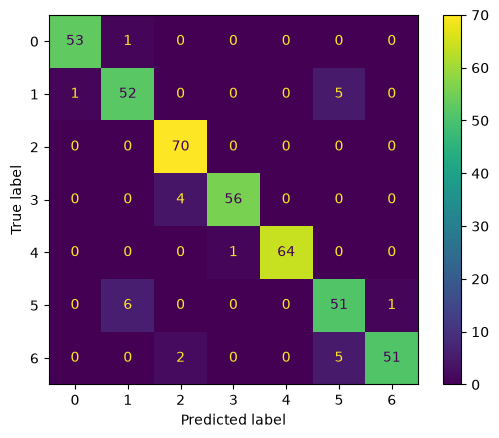

Trainable parameters: 39175
                    Model  Test Accuracy  Test Macro-F1  Parameters/Trees
0   Random Forest (Lab 2)       0.995272       0.995457               100
1  Feedforward NN (Lab 3)       0.938534       0.937600             39175


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# TODO: Load your best configuration's weights; model.eval().
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(256, 128), dropout=0.3).to(DEVICE)
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()
# TODO: Report test ACCURACY and MACRO-F1
all_predictions = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        preds = torch.argmax(logits, dim=1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)
test_f1_macro = f1_score(all_labels, all_predictions, average='macro')

print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_f1_macro)

# TODO: Confusion matrix for the test set with the 7 class names

ConfusionMatrixDisplay.from_predictions(all_labels, all_predictions)
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

comparison = pd.DataFrame({
    'Model': ['Random Forest (Lab 2)', 'Feedforward NN (Lab 3)'],
    'Test Accuracy': [0.9952718676122931, test_accuracy],
    'Test Macro-F1': [0.9954565354928734, test_f1_macro],
    'Parameters/Trees': [100, num_params]
})
print(comparison)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.